# adap-eps-greedy experiment results (last 36 prompts/classes)

This notebook loads logs from `logs/search_stats/adap_eps_greedy/EVAL`, reconstructs final reward per unit (prompt/class), computes NFE by method, and plots **mean reward (over 36 units)** vs NFE for each reward type.


In [15]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-whitegrid')


In [16]:
# -------- Config --------
ROOT = Path('../logs/search_stats/adap_eps_greedy/EVAL')
EXPECTED_UNITS = 36  # average reward over exactly 36 prompts/classes
KEEP_ONLY_COMPLETE = True

REWARD_KEY_MAP = {
    'BRIGHTNESS': ('brightness', 'Brightness'),
    'COMPRESSIBILITY': ('compressibility', 'Compressibility'),
    'CLIP': ('classifier_or_clip', 'Classifier / CLIP'),
    'CLASSIFIER': ('classifier_or_clip', 'Classifier / CLIP'),
}

METHOD_ORDER = ['naive', 'rejection', 'beam', 'mcts', 'zero_order', 'eps_greedy', 'adap_eps_greedy']
METHOD_LABELS = {
    'naive': 'Naive',
    'rejection': 'Best-of-N (Rejection)',
    'beam': 'Beam Search',
    'mcts': 'MCTS',
    'zero_order': 'Zero-Order',
    'eps_greedy': 'Eps-Greedy',
    'adap_eps_greedy': 'Adap-Eps-Greedy',
    'unknown': 'Unknown',
}
METHOD_COLORS = {
    'naive': '#1f77b4',
    'rejection': '#17becf',
    'beam': '#9467bd',
    'mcts': '#8c564b',
    'zero_order': '#ff7f0e',
    'eps_greedy': '#2ca02c',
    'adap_eps_greedy': '#d62728',
    'unknown': '#7f7f7f',
}
MODEL_MARKERS = {'SD': 'o', 'EDM': 's'}

ROOT


PosixPath('../logs/search_stats/adap_eps_greedy/EVAL')

In [17]:
def _to_float(x, default=np.nan):
    try:
        return float(x)
    except Exception:
        return float(default)


def _infer_method_from_path(path: Path):
    s = path.as_posix().lower()
    for m in ['adap_eps_greedy', 'eps_greedy', 'zero_order', 'rejection', 'beam', 'mcts', 'naive']:
        if f'_{m}_' in s or f'/{m}_' in s or s.endswith(f'_{m}.jsonl'):
            return m
    return 'unknown'


def _resolve_reward_key_label(reward_dir: str):
    return REWARD_KEY_MAP.get(reward_dir, (reward_dir.lower(), reward_dir.title()))


def _extract_prompt_or_class_id(event):
    if event.get('prompt_index') is not None:
        try:
            return int(event.get('prompt_index'))
        except Exception:
            pass
    if event.get('class_label_idx') is not None:
        try:
            return int(event.get('class_label_idx'))
        except Exception:
            pass
    return None


def parse_log_file(log_path: Path):
    run_meta = {}
    candidate_rows = []
    run_end_best_score = None

    with log_path.open('r', encoding='utf-8') as f:
        for line in f:
            if not line.strip():
                continue
            try:
                e = json.loads(line)
            except Exception:
                continue
            et = e.get('event_type')
            if et == 'run_meta' and isinstance(e.get('run_meta', None), dict):
                run_meta = e['run_meta']
            elif et == 'candidate_eval':
                candidate_rows.append(e)
            elif et == 'run_end' and e.get('best_score') is not None:
                try:
                    run_end_best_score = float(e['best_score'])
                except Exception:
                    pass

    method = str(run_meta.get('method') or _infer_method_from_path(log_path))
    params = run_meta.get('params', {}) if isinstance(run_meta.get('params', {}), dict) else {}

    backend = str(run_meta.get('backend', '')).lower()
    if backend == '':
        backend = 'edm' if '_edm_' in log_path.name.lower() else 'sd'

    # Reconstruct per-unit final score.
    out_rows = []

    if len(candidate_rows) == 0:
        if run_end_best_score is None:
            return out_rows, run_meta, params, method, backend
        out_rows.append({
            'unit_id': _extract_prompt_or_class_id(run_meta),
            'final_score': float(run_end_best_score),
        })
        return out_rows, run_meta, params, method, backend

    cdf = pd.DataFrame(candidate_rows)

    # unit_id: prefer sample_idx for multi-unit logs.
    if 'sample_idx' in cdf.columns:
        cdf['unit_id'] = cdf['sample_idx'].astype(int)
    else:
        cdf['unit_id'] = 0

    for unit_id, sub in cdf.groupby('unit_id', sort=True):
        if sub.empty:
            continue

        t_last = int(sub['timestep_idx'].max()) if 'timestep_idx' in sub.columns else None
        if t_last is not None:
            sub = sub[sub['timestep_idx'] == t_last]

        k_last = int(sub['local_iter_idx'].max()) if 'local_iter_idx' in sub.columns else None
        if k_last is not None:
            sub = sub[sub['local_iter_idx'] == k_last]

        win = sub[sub.get('is_winner', False) == True] if 'is_winner' in sub.columns else pd.DataFrame()
        if win.empty:
            if 'score' in sub.columns:
                idx = sub['score'].astype(float).idxmax()
                win = sub.loc[[idx]]
            else:
                win = sub.iloc[[0]]

        row = win.iloc[0]
        score = row.get('winner_score', row.get('score', np.nan))
        try:
            score = float(score)
        except Exception:
            continue

        out_rows.append({
            'unit_id': int(unit_id),
            'final_score': score,
        })

    # if exactly one unit in file and run_end exists, use run_end as final score
    if len(out_rows) == 1 and (run_end_best_score is not None):
        out_rows[0]['final_score'] = float(run_end_best_score)

    return out_rows, run_meta, params, method, backend


def compute_nfe(method, params, backend, t_observed_max=None):
    method = str(method)

    # T: prefer explicit metadata, then observed max timestep + 1, else backend default.
    T = None
    if params.get('num_steps') is not None:
        T = int(_to_float(params.get('num_steps'), np.nan))
    if (T is None or not np.isfinite(T)) and (t_observed_max is not None):
        T = int(t_observed_max + 1)
    if T is None or not np.isfinite(T) or T <= 0:
        T = 18 if str(backend).lower() == 'edm' else 50

    N = int(round(_to_float(params.get('N', 4), 4)))
    K = int(round(_to_float(params.get('K', 20), 20)))
    B = int(round(_to_float(params.get('B', 2), 2)))
    S = int(round(_to_float(params.get('S', 8), 8)))
    Kg = int(round(_to_float(params.get('adap_Kg', 4), 4)))
    eps = _to_float(params.get('eps', np.nan), np.nan)
    lam = _to_float(params.get('lambda', params.get('lambda_param', np.nan)), np.nan)
    alpha_q = _to_float(params.get('adap_alpha_quantile', np.nan), np.nan)

    # p_below threshold for adap-eps-greedy.
    p_below = np.nan
    q_realized = _to_float(params.get('adap_alpha_quantile_realized_frac_le', np.nan), np.nan)
    q_requested = _to_float(params.get('adap_alpha_quantile', np.nan), np.nan)

    if np.isfinite(q_realized):
        p_below = q_realized
    elif np.isfinite(q_requested):
        p_below = q_requested
    else:
        z_vec = params.get('adap_z_profile', params.get('adap_z', None))
        alpha = _to_float(params.get('adap_alpha', np.nan), np.nan)
        if z_vec is not None:
            try:
                z = np.asarray(z_vec, dtype=float).reshape(-1)
                if z.size > 0 and np.isfinite(alpha):
                    p_below = float(np.mean(z <= alpha))
            except Exception:
                pass

    if np.isfinite(p_below):
        p_below = float(np.clip(p_below, 0.0, 1.0))

    # Requested formulas.
    if method == 'naive':
        nfe = float(T)
        hp = f'T={T}'
    elif method == 'rejection':
        nfe = float(N * T)
        hp = f'N={N}, T={T}'
    elif method == 'beam':
        nfe = float((N * B) * T)
        hp = f'N={N}, B={B}, T={T}'
    elif method == 'mcts':
        nfe = float((N + S) * (T ** 2))
        hp = f'N={N}, S={S}, T={T}'
    elif method == 'zero_order':
        nfe = float(N * K * T)
        hp = f'N={N}, K={K}, eps={eps:.3g}, lambda={lam:.3g}, T={T}'
    elif method == 'eps_greedy':
        nfe = float(N * K * T)
        hp = f'N={N}, K={K}, eps={eps:.3g}, lambda={lam:.3g}, T={T}'
    elif method == 'adap_eps_greedy':
        if not np.isfinite(p_below):
            p_below = 0.5
        p_above = 1.0 - p_below
        # User requested: (% below)*T*Ng + (% above)*T*N*K
        nfe = float((p_below * T * Kg) + (p_above * T * N * K))
        hp = f'N={N}, K={K}, Kg={Kg}, eps={eps:.3g}, lambda={lam:.3g}, alpha_q={alpha_q:.3g}, p_below={p_below:.2f}, T={T}'
    else:
        nfe = np.nan
        hp = ''

    return float(nfe), hp, dict(T=T, N=N, K=K, B=B, S=S, Kg=Kg, p_below=p_below)


In [18]:
# -------- Load all EVAL logs --------
rows = []

if not ROOT.exists():
    raise RuntimeError(f'Missing log root: {ROOT.resolve()}')

for model_dir in sorted([p for p in ROOT.iterdir() if p.is_dir()]):
    model = model_dir.name

    for reward_dir_path in sorted([p for p in model_dir.iterdir() if p.is_dir()]):
        reward_dir = reward_dir_path.name
        reward_key, reward_label = _resolve_reward_key_label(reward_dir)

        for log_path in sorted(reward_dir_path.rglob('*.jsonl')):
            per_unit, run_meta, params, method, backend = parse_log_file(log_path)
            if len(per_unit) == 0:
                continue

            # observed max timestep from candidate rows, if available
            t_obs = None
            try:
                with log_path.open('r', encoding='utf-8') as f:
                    tvals = []
                    for line in f:
                        if '"event_type": "candidate_eval"' not in line:
                            continue
                        e = json.loads(line)
                        if e.get('timestep_idx') is not None:
                            tvals.append(int(e['timestep_idx']))
                if len(tvals) > 0:
                    t_obs = max(tvals)
            except Exception:
                pass

            nfe, hp_label, nmeta = compute_nfe(method, params, backend, t_observed_max=t_obs)

            for u in per_unit:
                rows.append({
                    'source': str(log_path),
                    'model': model,
                    'reward_dir': reward_dir,
                    'reward_key': reward_key,
                    'reward_label': reward_label,
                    'method': method,
                    'method_label': METHOD_LABELS.get(method, method),
                    'unit_id': u['unit_id'],
                    'final_score': float(u['final_score']),
                    'nfe': nfe,
                    'hp_label': hp_label,
                    **nmeta,
                })

if len(rows) == 0:
    raise RuntimeError('No usable rows found in EVAL logs.')

units_df = pd.DataFrame(rows)
units_df.head()


,source,model,reward_dir,reward_key,reward_label,method,method_label,unit_id,final_score,nfe,hp_label,T,N,K,B,S,Kg,p_below
0,../logs/search_stats/adap_eps_greedy/EVAL/SD/B...,SD,BRIGHTNESS,brightness,Brightness,adap_eps_greedy,Adap-Eps-Greedy,0,0.609832,556.0,"N=4, K=10, Kg=2, eps=0.2, lambda=0.15, alpha_q...",50,4,10,2,8,2,0.76
1,../logs/search_stats/adap_eps_greedy/EVAL/SD/B...,SD,BRIGHTNESS,brightness,Brightness,adap_eps_greedy,Adap-Eps-Greedy,0,0.678306,556.0,"N=4, K=10, Kg=2, eps=0.2, lambda=0.15, alpha_q...",50,4,10,2,8,2,0.76
2,../logs/search_stats/adap_eps_greedy/EVAL/SD/B...,SD,BRIGHTNESS,brightness,Brightness,adap_eps_greedy,Adap-Eps-Greedy,0,0.669113,556.0,"N=4, K=10, Kg=2, eps=0.2, lambda=0.15, alpha_q...",50,4,10,2,8,2,0.76
3,../logs/search_stats/adap_eps_greedy/EVAL/SD/B...,SD,BRIGHTNESS,brightness,Brightness,adap_eps_greedy,Adap-Eps-Greedy,0,0.657951,556.0,"N=4, K=10, Kg=2, eps=0.2, lambda=0.15, alpha_q...",50,4,10,2,8,2,0.76
4,../logs/search_stats/adap_eps_greedy/EVAL/SD/B...,SD,BRIGHTNESS,brightness,Brightness,adap_eps_greedy,Adap-Eps-Greedy,0,0.591182,556.0,"N=4, K=10, Kg=2, eps=0.2, lambda=0.15, alpha_q...",50,4,10,2,8,2,0.76


In [19]:
# -------- Aggregate over prompts/classes --------
summary = (
    units_df
    .groupby(['model', 'reward_key', 'reward_label', 'method', 'method_label', 'nfe', 'hp_label'], as_index=False)
    .agg(
        mean_reward=('final_score', 'mean'),
        se_reward=('final_score', 'sem'),
        n_units=('final_score', 'count'),
    )
)
summary['se_reward'] = summary['se_reward'].fillna(0.0)

if KEEP_ONLY_COMPLETE:
    summary_plot = summary[summary['n_units'] == EXPECTED_UNITS].copy()
else:
    summary_plot = summary.copy()

method_rank = {m: i for i, m in enumerate(METHOD_ORDER)}
summary_plot['method_rank'] = summary_plot['method'].map(method_rank).fillna(999)
summary_plot = summary_plot.sort_values(['reward_key', 'model', 'method_rank', 'nfe']).drop(columns=['method_rank']).reset_index(drop=True)

print('Rows used for plotting:', len(summary_plot))
print('Units per model/reward/method (after filtering):')
print(
    summary_plot[['model', 'reward_label', 'method_label', 'n_units']]
    .sort_values(['model', 'reward_label', 'method_label'])
    .to_string(index=False)
)

summary_plot


Rows used for plotting: 24
Units per model/reward/method (after filtering):
model      reward_label          method_label  n_units
   SD        Brightness       Adap-Eps-Greedy       36
   SD        Brightness       Adap-Eps-Greedy       36
   SD        Brightness           Beam Search       36
   SD        Brightness Best-of-N (Rejection)       36
   SD        Brightness            Eps-Greedy       36
   SD        Brightness                  MCTS       36
   SD        Brightness                 Naive       36
   SD        Brightness            Zero-Order       36
   SD Classifier / CLIP       Adap-Eps-Greedy       36
   SD Classifier / CLIP       Adap-Eps-Greedy       36
   SD Classifier / CLIP           Beam Search       36
   SD Classifier / CLIP Best-of-N (Rejection)       36
   SD Classifier / CLIP            Eps-Greedy       36
   SD Classifier / CLIP                  MCTS       36
   SD Classifier / CLIP                 Naive       36
   SD Classifier / CLIP            Zero-Orde

,model,reward_key,reward_label,method,method_label,nfe,hp_label,mean_reward,se_reward,n_units
0,SD,brightness,Brightness,naive,Naive,50.0,T=50,0.458313,0.012418,36
1,SD,brightness,Brightness,rejection,Best-of-N (Rejection),200.0,"N=4, T=50",0.525445,0.009407,36
2,SD,brightness,Brightness,beam,Beam Search,400.0,"N=4, B=2, T=50",0.673363,0.011634,36
3,SD,brightness,Brightness,mcts,MCTS,30000.0,"N=4, S=8, T=50",0.463664,0.012973,36
4,SD,brightness,Brightness,zero_order,Zero-Order,4000.0,"N=4, K=20, eps=0.4, lambda=0.15, T=50",0.665915,0.011312,36
5,SD,brightness,Brightness,eps_greedy,Eps-Greedy,4000.0,"N=4, K=20, eps=0.4, lambda=0.15, T=50",0.800706,0.009754,36
6,SD,brightness,Brightness,adap_eps_greedy,Adap-Eps-Greedy,556.0,"N=4, K=10, Kg=2, eps=0.2, lambda=0.15, alpha_q...",0.669408,0.012394,36
7,SD,brightness,Brightness,adap_eps_greedy,Adap-Eps-Greedy,1112.0,"N=4, K=20, Kg=4, eps=0.4, lambda=0.15, alpha_q...",0.731295,0.012479,36
8,SD,classifier_or_clip,Classifier / CLIP,naive,Naive,50.0,T=50,0.254255,0.004320,36
9,SD,classifier_or_clip,Classifier / CLIP,rejection,Best-of-N (Rejection),200.0,"N=4, T=50",0.265680,0.004131,36


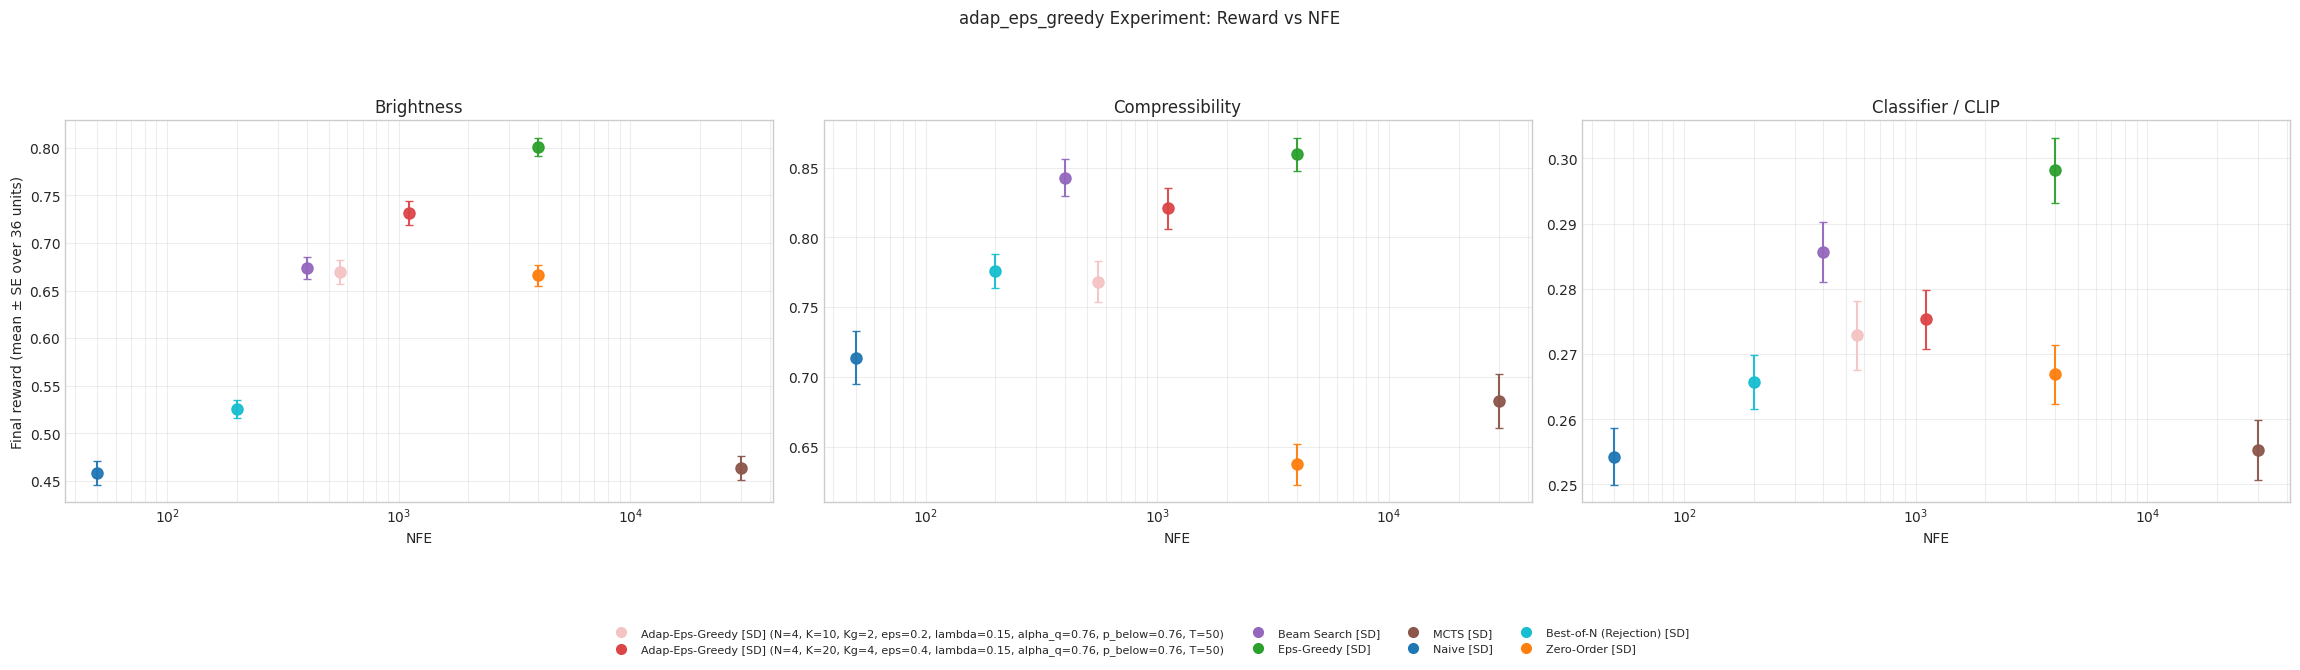

In [20]:
# -------- Plot: mean reward over 36 units vs NFE --------
reward_order = ['brightness', 'compressibility', 'classifier_or_clip']
reward_order = [rk for rk in reward_order if rk in summary_plot['reward_key'].unique()]


def _mix_with_white(color_hex, amount):
    # amount in [0,1]: 0 keeps original color, 1 becomes white
    base = np.array(mcolors.to_rgb(color_hex), dtype=float)
    white = np.ones(3, dtype=float)
    out = (1.0 - amount) * base + amount * white
    return tuple(np.clip(out, 0.0, 1.0))


# Methods that actually have multiple hparam variants.
method_hp_counts = summary_plot.groupby('method')['hp_label'].nunique()
multi_hparam_methods = set(method_hp_counts[method_hp_counts > 1].index.tolist())
use_shading = len(multi_hparam_methods) > 0

# Global per-method NFE spans so shade mapping is consistent across all panels.
method_nfe_span_global = (
    summary_plot.groupby('method', as_index=False)['nfe']
    .agg(nfe_min='min', nfe_max='max')
    .set_index('method')
)

fig, axes = plt.subplots(1, len(reward_order), figsize=(7.7 * max(1, len(reward_order)), 5.8), sharey=False)
if len(reward_order) == 1:
    axes = [axes]

legend_handles = []
seen_legend = set()

for ax, rk in zip(axes, reward_order):
    sub = summary_plot[summary_plot['reward_key'] == rk].copy()

    if sub.empty:
        ax.text(0.5, 0.5, 'No complete data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(rk)
        continue

    sub = sub.sort_values(['method', 'nfe', 'model']).reset_index(drop=True)

    for _, r in sub.iterrows():
        method = r['method']
        model = r['model']

        base_color = METHOD_COLORS.get(method, '#7f7f7f')
        marker = MODEL_MARKERS.get(model, 'o')

        # Shade by NFE only for methods with multiple hparam sets.
        if use_shading and method in multi_hparam_methods:
            nfe_min = float(method_nfe_span_global.loc[method, 'nfe_min'])
            nfe_max = float(method_nfe_span_global.loc[method, 'nfe_max'])
            if nfe_max > nfe_min:
                ratio = (float(r['nfe']) - nfe_min) / (nfe_max - nfe_min)
            else:
                ratio = 0.5

            # lower NFE => lighter shade
            whiten = 0.72 - 0.58 * ratio
            whiten = float(np.clip(whiten, 0.12, 0.85))
            color = _mix_with_white(base_color, whiten)
        else:
            color = base_color

        ax.errorbar(
            r['nfe'], r['mean_reward'],
            yerr=r['se_reward'],
            fmt=marker,
            linestyle='none',
            color=color,
            ecolor=color,
            markersize=8,
            capsize=3,
            alpha=0.95,
        )

        if use_shading and method in multi_hparam_methods:
            label = f"{METHOD_LABELS.get(method, method)} [{model}] ({r['hp_label']})"
        else:
            label = f"{METHOD_LABELS.get(method, method)} [{model}]"

        if label not in seen_legend:
            seen_legend.add(label)
            legend_handles.append(
                Line2D([0], [0], marker=marker, color=color, linestyle='None', markersize=7, label=label)
            )

    ax.set_xscale('log')
    ax.set_xlabel('NFE')
    ax.set_title(sub['reward_label'].iloc[0])
    ax.grid(True, which='both', alpha=0.35)

axes[0].set_ylabel(f'Final reward (mean ± SE over {EXPECTED_UNITS} units)')

# One legend outside, centered under the middle panel.
fig.legend(
    handles=legend_handles,
    frameon=False,
    fontsize=8,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=min(4, max(1, len(legend_handles))),
)

fig.suptitle('adap_eps_greedy Experiment: Reward vs NFE', y=1.03)
plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()


In [21]:
# Optional compact table
summary_plot[['model', 'reward_label', 'method_label', 'nfe', 'mean_reward', 'se_reward', 'n_units']].sort_values(
    ['model', 'reward_label', 'nfe', 'method_label']
).reset_index(drop=True)


,model,reward_label,method_label,nfe,mean_reward,se_reward,n_units
0,SD,Brightness,Naive,50.0,0.458313,0.012418,36
1,SD,Brightness,Best-of-N (Rejection),200.0,0.525445,0.009407,36
2,SD,Brightness,Beam Search,400.0,0.673363,0.011634,36
3,SD,Brightness,Adap-Eps-Greedy,556.0,0.669408,0.012394,36
4,SD,Brightness,Adap-Eps-Greedy,1112.0,0.731295,0.012479,36
5,SD,Brightness,Eps-Greedy,4000.0,0.800706,0.009754,36
6,SD,Brightness,Zero-Order,4000.0,0.665915,0.011312,36
7,SD,Brightness,MCTS,30000.0,0.463664,0.012973,36
8,SD,Classifier / CLIP,Naive,50.0,0.254255,0.004320,36
9,SD,Classifier / CLIP,Best-of-N (Rejection),200.0,0.265680,0.004131,36
